# **Comparison Study of Modern Symmetric Cryptographic Algorithms**

In this notebook, we analyze three commonly used symmetric encryption algorithms: **AES-GCM, AES_CCM, and ChaCha20-Poly1305**.

The goal of this study is to compare these algrithms in terms of **performance** to determine which is best suited for implementing **end-to-end encryption (E2EE)** and encrypting files.

## **1. Imports and setup**

In [239]:
# Core libraries
import time
import os
import psutil
import tracemalloc

# Cryptography library
from cryptography.hazmat.primitives.ciphers.aead import AESGCM, AESCCM, ChaCha20Poly1305

# Plot
import matplotlib.pyplot as plt
import numpy as np

## **2. Helper functions**

In [ ]:
def measure_cpu(func, *args, **kwargs):
    process = psutil.Process(os.getpid())
    cpu_before = process.cpu_times().user + process.cpu_times().system
    result = func(*args, **kwargs)
    cpu_after = process.cpu_times().user + process.cpu_times().system
    return result, cpu_after - cpu_before


def measure_memory(func, *args, **kwargs):
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss / (1024 * 1024)
    result = func(*args, **kwargs)
    mem_after = process.memory_info().rss / (1024 * 1024)
    return result, mem_after - mem_before


def measure_memory_tracemalloc(func, *args, **kwargs):
    tracemalloc.start()
    result = func(*args, **kwargs)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result, peak / (1024 * 1024)


def measure_time(func, *args, **kwargs):
    start = time.time()
    result = func(*args, **kwargs)
    end = time.time()
    return result, end - start


def decryption_validation(decrypted: bytes, plaintext: bytes):
    assert decrypted == plaintext, "Decryption failed"


def generate_plaintext(data_size) -> bytes:
    plaintext = os.urandom(data_size)
    return plaintext


def plot_times(
    data_sizes_mb: list[int], times_dict: dict, title: str, ylabel: str
) -> None:
    """
    Plot encryption or decryption times for multiple algrithms

    Parameters
        - data_sizes_mb: list of data sizes in MB
        - times_dict: dictionary { algorithm_name: list_of_time }
        - title: plot title
        - ylabel: label for Y-axis
    """
    plt.figure(figsize=(8, 5))

    for algorithm, times in times_dict.items():
        # Replace None with np.nan for plotting
        times = [t if t is not None else np.nan for t in times]
        plt.plot(data_sizes_mb, times, marker="o", label=algorithm)

    plt.xticks(data_sizes_mb[2:], rotation=0)
    plt.xlabel("Data size (MB)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

## **3. Data sizes for benchmarking**

In [ ]:
# Data sizes in bytes
data_sizes = [
    1 * 1024,  # 1 KB
    10 * 1024,  # 10 KB
    1 * 1024 * 1024,  # 1 MB
    5 * 1024 * 1024,  # 5 MB
    10 * 1024 * 1024,  # 10 MB
    16 * 1024 * 1024,  # 10 MB
    32 * 1024 * 1024,  # 10 MB
    50 * 1024 * 1024,  # 50 MB
    100 * 1024 * 1024,  # 100 MB
]

## **4. Benhmark AES-GCM**

In [243]:
def aes_gcm_benchmark(key: bytes, plaintext: bytes) -> dict:
    aesgcm = AESGCM(key)
    nonce = os.urandom(12)

    try:
        # CPU profiling
        enc, cpu_enc = measure_cpu(aesgcm.encrypt, nonce, plaintext, None)
        dec, cpu_dec = measure_cpu(aesgcm.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        cpu_enc = cpu_dec = None

    try:
        # Memory profiling
        enc, mem_enc = measure_memory_tracemalloc(aesgcm.encrypt, nonce, plaintext, None)
        dec, mem_dec = measure_memory_tracemalloc(aesgcm.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        mem_enc = mem_dec = None

    try:
        # Wall-clock time
        enc, time_enc = measure_time(aesgcm.encrypt, nonce, plaintext, None)
        dec, time_dec = measure_time(aesgcm.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        time_enc = time_dec = None

    return {
        "encryption_time": time_enc,
        "decryption_time": time_dec,
        "encryption_cpu_sec": cpu_enc,
        "encryption_mem_mb": mem_enc,
        "decryption_cpu_sec": cpu_dec,
        "decryption_mem_mb": mem_dec,
    }


key = AESGCM.generate_key(bit_length=256)

aes_gcm_enc_time = []
aes_gcm_dec_time = []
aes_gcm_cpu_usage_enc = []
aes_gcm_cpu_usage_dec = []
aes_gcm_mem_usage_enc = []
aes_gcm_mem_usage_dec = []

for data_size in data_sizes:
    plaintext = generate_plaintext(data_size)
    results = aes_gcm_benchmark(key, plaintext)
    aes_gcm_enc_time.append(results["encryption_time"])
    aes_gcm_dec_time.append(results["decryption_time"])
    aes_gcm_cpu_usage_enc.append(results["encryption_cpu_sec"])
    aes_gcm_cpu_usage_dec.append(results["decryption_cpu_sec"])
    aes_gcm_mem_usage_enc.append(results["encryption_mem_mb"])
    aes_gcm_mem_usage_dec.append(results["decryption_mem_mb"])

## **5. Benhmark AES-CCM**

In [244]:
def aes_ccm_benchmark(key: bytes, plaintext: bytes) -> dict:
    aesccm = AESCCM(key)
    nonce = os.urandom(12)

    try:
        # CPU profiling
        enc, cpu_enc = measure_cpu(aesccm.encrypt, nonce, plaintext, None)
        dec, cpu_dec = measure_cpu(aesccm.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        cpu_enc = cpu_dec = None

    try:
        # Memory profiling
        enc, mem_enc = measure_memory_tracemalloc(aesccm.encrypt, nonce, plaintext, None)
        dec, mem_dec = measure_memory_tracemalloc(aesccm.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        mem_enc = mem_dec = None

    try:
        # Wall-clock time
        enc, time_enc = measure_time(aesccm.encrypt, nonce, plaintext, None)
        dec, time_dec = measure_time(aesccm.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        time_enc = time_dec = None

    return {
        "encryption_time": time_enc,
        "decryption_time": time_dec,
        "encryption_cpu_sec": cpu_enc,
        "encryption_mem_mb": mem_enc,
        "decryption_cpu_sec": cpu_dec,
        "decryption_mem_mb": mem_dec,
    }


key = AESCCM.generate_key(bit_length=256)

aes_ccm_enc_time = []
aes_ccm_dec_time = []
aes_ccm_cpu_usage_enc = []
aes_ccm_cpu_usage_dec = []
aes_ccm_mem_usage_enc = []
aes_ccm_mem_usage_dec = []

for data_size in data_sizes:
    plaintext = generate_plaintext(data_size)
    results = aes_ccm_benchmark(key, plaintext)
    aes_ccm_enc_time.append(results["encryption_time"])
    aes_ccm_dec_time.append(results["decryption_time"])
    aes_ccm_cpu_usage_enc.append(results["encryption_cpu_sec"])
    aes_ccm_cpu_usage_dec.append(results["decryption_cpu_sec"])
    aes_ccm_mem_usage_enc.append(results["encryption_mem_mb"])
    aes_ccm_mem_usage_dec.append(results["decryption_mem_mb"])

## **6. Benhmark ChaCha20-Poly1305**

In [245]:
def chacha20_poly1305_benchmark(key: bytes, plaintext: bytes) -> dict:
    chacha = ChaCha20Poly1305(key)
    nonce = os.urandom(12)

    try:
        # CPU profiling
        enc, cpu_enc = measure_cpu(chacha.encrypt, nonce, plaintext, None)
        dec, cpu_dec = measure_cpu(chacha.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        cpu_enc = cpu_dec = None

    try:
        # Memory profiling
        enc, mem_enc = measure_memory_tracemalloc(chacha.encrypt, nonce, plaintext, None)
        dec, mem_dec = measure_memory_tracemalloc(chacha.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        mem_enc = mem_dec = None

    try:
        # Wall-clock time
        enc, time_enc = measure_time(chacha.encrypt, nonce, plaintext, None)
        dec, time_dec = measure_time(chacha.decrypt, nonce, enc, None)
        decryption_validation(dec, plaintext)
    except Exception:
        time_enc = time_dec = None

    return {
        "encryption_time": time_enc,
        "decryption_time": time_dec,
        "encryption_cpu_sec": cpu_enc,
        "encryption_mem_mb": mem_enc,
        "decryption_cpu_sec": cpu_dec,
        "decryption_mem_mb": mem_dec,
    }


key = ChaCha20Poly1305.generate_key()

chacha_enc_time = []
chacha_dec_time = []
chacha_cpu_usage_enc = []
chacha_cpu_usage_dec = []
chacha_mem_usage_enc = []
chacha_mem_usage_dec = []

for data_size in data_sizes:
    plaintext = generate_plaintext(data_size)
    results = chacha20_poly1305_benchmark(key, plaintext)
    chacha_enc_time.append(results["encryption_time"])
    chacha_dec_time.append(results["decryption_time"])
    chacha_cpu_usage_enc.append(results["encryption_cpu_sec"])
    chacha_cpu_usage_dec.append(results["decryption_cpu_sec"])
    chacha_mem_usage_enc.append(results["encryption_mem_mb"])
    chacha_mem_usage_dec.append(results["decryption_mem_mb"])

## **7. Plot Wall-Clock Time**

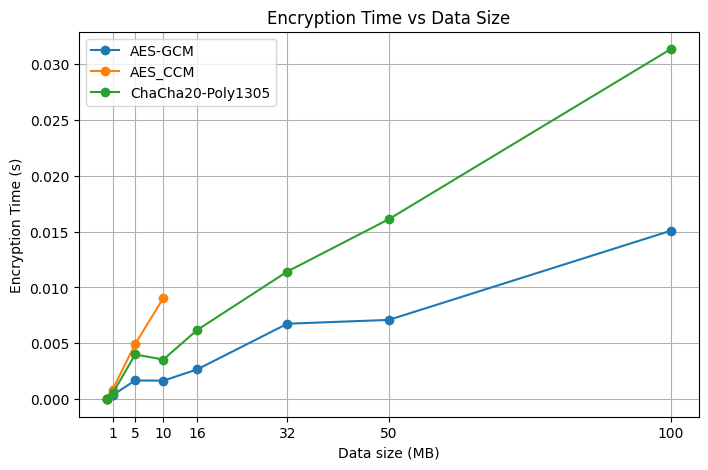

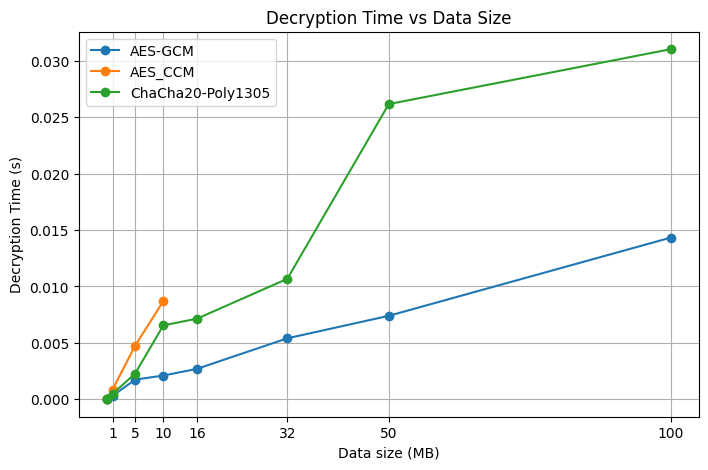

In [252]:
# Convert data sizes in MB
sizes_mb = [s / (1024 * 1024) for s in data_sizes]

# Encryption times
encryption_times = {
    "AES-GCM": aes_gcm_enc_time,
    "AES_CCM": aes_ccm_enc_time,
    "ChaCha20-Poly1305": chacha_enc_time,
}

# Decryption times
decryption_times = {
    "AES-GCM": aes_gcm_dec_time,
    "AES_CCM": aes_ccm_dec_time,
    "ChaCha20-Poly1305": chacha_dec_time,
}

plot_times(
    data_sizes_mb=sizes_mb,
    times_dict=encryption_times,
    title="Encryption Time vs Data Size",
    ylabel="Encryption Time (s)",
)
plot_times(
    sizes_mb,
    decryption_times,
    title="Decryption Time vs Data Size",
    ylabel="Decryption Time (s)",
)

## **8. Plot CPU Time**

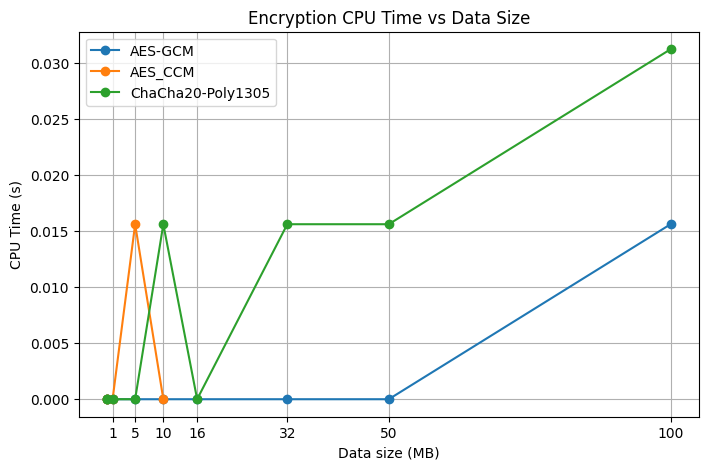

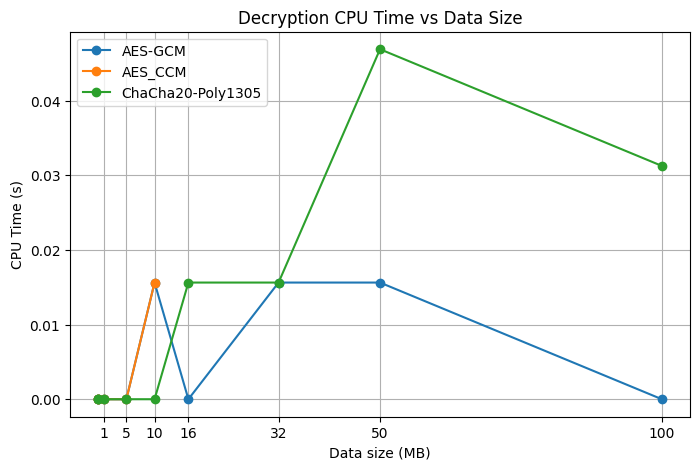

In [256]:
# Encryption times
encryption_times = {
    "AES-GCM": aes_gcm_cpu_usage_enc,
    "AES_CCM": aes_ccm_cpu_usage_enc,
    "ChaCha20-Poly1305": chacha_cpu_usage_enc,
}

# Decryption times
decryption_times = {
    "AES-GCM": aes_gcm_cpu_usage_dec,
    "AES_CCM": aes_ccm_cpu_usage_dec,
    "ChaCha20-Poly1305": chacha_cpu_usage_dec,
}

plot_times(
    data_sizes_mb=sizes_mb,
    times_dict=encryption_times,
    title="Encryption CPU Time vs Data Size",
    ylabel="CPU Time (s)",
)
plot_times(
    sizes_mb,
    decryption_times,
    title="Decryption CPU Time vs Data Size",
    ylabel="CPU Time (s)",
)

## **Conclusions of Symmetric Encryption Benchmark**

The benchmark results reveal nuanced performance differences among AES-GCM, AES-CCM, and ChaCha20-Poly1305. For small file sizes, AES-CCM performs comparably to both ChaCha20-Poly1305 and AES-GCM, with only minor differences in encryption and decryption times. This suggests that for lightweight data, AES-CCM is efficient and competitive. However, AES-CCM is inherently limited by maximum file size, making it unsuitable for encrypting larger files.

ChaCha20-Poly1305 and AES-GCM show similar performance trends for small files, with encryption and decryption times increasing roughly in parallel. As file sizes grow, a divergence becomes clear: AES-GCM maintains low wall-clock times and consistent performance even for large files, while ChaCha20-Poly1305 experiences more pronounced increases in processing time. This indicates that AES-GCM scales better with file size, offering faster and more predictable performance for large payloads.

CPU usage measurements further support this conclusion. AES-GCM consistently consumes the least CPU time across all tested data sizes, while ChaCha20-Poly1305 uses slightly more CPU, particularly for large files. AES-CCM remains efficient for small files but cannot process data beyond its size limit. Memory usage is similar across all algorithms for the data sizes they can handle, so memory is not a differentiating factor in practical applications.

Considering real-world use cases, AES-CCM is best suited for small, lightweight messages, such as IoT communications or embedded systems. ChaCha20-Poly1305 can handle larger files and is a strong option when AES hardware acceleration is unavailable, such as on some mobile or cross-platform applications. However, AES-GCM demonstrates the best overall combination of speed, CPU efficiency, and scalability, making it the most suitable choice for end-to-end encryption and file encryption in modern applications. Its ability to handle large files while keeping encryption and decryption times low ensures a smooth user experience without noticeable delays.

In summary, while each algorithm has its strengths, **AES-GCM stands out** as the optimal choice for secure and efficient encryption in applications where performance and user experience are critical.